<div style="border:1px solid black; padding:10px 10px;">
    <strong>CIVIL-321 "Modélisation Numérique des Solides et Structures"</strong><br/><br/>
    <span style="text-decoration:underline;font-weight:bold;">Comment utiliser ce Jupyter Notebook?
    </span><br/><br/>
    Ce <strong>Notebook</strong> est constitué de cellules de texte et de cellule de code. Les cellules de codes doivent être  <strong>executées</strong> pour voir le résultat du programme. Certaines cellules doivent être remplies par vos soins. Pour exécuter une cellule, cliquez dessus simplement et ensuite cliquez sur le bouton "play" (<span style="font: bold 12px/30px Arial, serif;">&#9658;</span>) dans la barre de menu au dessus du notebook. Vous pouvez aussi taper la combinaison de touches <code>shift + enter</code>. Il est important d'éxécuter les cellules de code en respectant leur ordre d'arrivée dans le notebook.
</div>

On vous encourage à poser vos questions et donner votre feedback sur ce notebook sur la plateforme ED Discussion du cours accessible en cliquant sur ce bouton:
 
 
 
<div class="container" >
        <a href="https://edstem.org/eu/courses/409/discussion?category=Exercices">
            <button class="btn btn-primary btn-lg">Ed Discussion</button>
        </a>
</div>

# Série d'exercices : Éléments solides 2D - Triangles

In [1]:
import numpy as np
import math as m
from utils import *
from sympy import *
from IPython.display import Image

#### Exercice 1 

On fait une (mauvaise) modélisation du barrage suivant en négligeant le poids propre :

![](Images/modele_barrage.png)

On approxime la structure de ce barrage avec un élément linéaire triangulaire, d'épaisseur $w$, avec des appuis indiqués sur le schéma ci-dessus et une loi de constitution linéaire élastique et isotrope avec $\lambda$ et $\mu$ les coefficients de Lamé. Le bord $1-3$ est libre tandis que le bord $2-3$ subit la traction $t_e$ imposée par l'eau qui est linéaire par morceaux :

$$
t_e(y) = \begin{cases}
  - w \rho_e g \left( h_e - y \right) & \text{si } y < h_e \\
  0 & \text{si } y \geq h_e
\end{cases}
$$

avec $\rho_e$ la masse volumique de l'eau et $g$ la constante de gravité. 


1. Donner le tableau des conditions aux limites pour ce problème.

SolutionToRemove

![](Images/TableauBC.png)

2. Calculez les fonctions d'interpolation de l'élément $123$ en utilisant le système d'axe proposé.

SolutionToRemove

$$ N_1 = - \frac{x}{L} $$
$$ N_2 = 1 + \frac{x}{L} - \frac{y}{h} $$
$$ N_3 = \frac{y}{h} $$

3. Calculez la force consistante s'appliquant aux noeuds de l'élément (en négligeant le poids propre du barrage).

SolutionToRemove

$$
t_{i,x} = \int_0^h t(y)N_i(y)dY=\int_0^{h_e} t(y)N_i(y)dY 
$$

$$
\begin{bmatrix}
t_{2,x} \\ 
t_{3,x}
\end{bmatrix}
= 
\begin{bmatrix}
\frac{w \rho_e g h_e^3}{6h} -\frac{w}{2}\rho_e gh_e^2 \\ 
-\frac{w \rho_e g h_e^3}{6h}
\end{bmatrix}
$$

4. Calculez la matrice $B(x,y)$.

SolutionToRemove
$$
B=\begin{bmatrix}
        \frac{\partial N_1}{\partial x} & 0 & \frac{\partial N_2}{\partial x} & 0 & \frac{\partial N_3}{\partial x} & 0  \\[0.3em]
        0 & \frac{\partial N_1}{\partial y } & 0 & \frac{\partial N_2}{\partial y} & 0 & \frac{\partial N_3}{\partial y} \\[0.3em]
        \frac{\partial N_1}{\partial y} & \frac{\partial N_1}{\partial x} & \frac{\partial N_2}{\partial y} & \frac{\partial N_2}{\partial x} & \frac{\partial N_3}{\partial y} & \frac{\partial N_3}{\partial x}
\end{bmatrix}
=
\begin{bmatrix}
      -\frac{1}{L} & 0 & \frac{1}{L} & 0 & 0 & 0 \\[0.3em]
      0 & 0 & 0 & -\frac{1}{h} & 0 & \frac{1}{h} \\[0.3em]
      0 & -\frac{1}{L} & -\frac{1}{h} & \frac{1}{L} & \frac{1}{h} & 0
\end{bmatrix}
$$

#### Exercice 2

Le but de cet exercice est de calculer les fonctions d'interpolation pour un triangle
en utilisant la technique des monomes. On rappelle ci-dessous le principe de cette méthode.

![](Images/Exo2_exemple.png)

En faisant l'hypothèse d'une interpolation polynomial, on peut décrire tout champ sous la forme:
$$
\begin{align*}
P(x,y)  &= a_0 + a_1 x + a_2 y + a_3 x^2 + a_4 xy + a_5 y^2 + ... = \{M(x,y)^t \} \cdot \{A\}\\
\{M(x,y)^t\} &= \left\{ 1, x, y, x^2, xy, y^2,  ... \right\} \qquad 
\{A^t\} = \left\{ a_0, a_1, a_2, a_3, a_4, a_5,  ... \right\}                    
\end{align*}
$$

les monômes dans $\{ M \}$ sont donnés par le triangle de Pascal et $\{A\}$ est le vecteur des coefficients polynômiaux. La valeur de $P(x, y)$ interpolée sur les noeuds du triangle doit donner la valeur nodale du champ $P$. Pour les trois noeuds on obtient:
$$
\begin{equation*}
  \{ M(0, 0)^t \} \cdot \{A\} = P_1 ,\qquad   \{ M(1, 0)^t \} \cdot \{A\} = P_2 , \qquad  \{ M(0, 1)^t \} \cdot \{A\} = P_3
\end{equation*}
$$

Ce qui donne en matriciel:
$$
\begin{equation*}
\underbrace{
\left(
\begin{array}{c}
  \{ M(0,0)^t \} \\
  \{ M(1,0)^t \} \\
  \{ M(0,1)^t \} \\
\end{array}
\right)}_{[C]} \cdot \{A\} = \left\{
\begin{array}{c}
  P_1 \\
  P_2 \\
  P_3 \\
\end{array}
\right\}
\end{equation*}
$$
Pour que ce système soit inversible, $[C]$ doit être carrée: on considèrere seulement les premiers monômes $(1, x, y)$. On en déduit le vecteur $\{A\}$ qui caractérise les fonctions d'interpolations du champ $P(x, y)$:
$$
\begin{equation*}
\{A\} = [ C^{-1} ] \cdot \left\{
\begin{array}{c}
  P_1  \\
  P_2  \\
  P_3 
\end{array}
\right\} \quad \Longrightarrow
P(x,y)  = \underbrace{ \{M(x,y)^t\} \cdot [C^{-1}] }_{\{N^t(x, y)\}}\cdot \left\{
\begin{array}{c}
  P_1 \\
  P_2 \\
  P_3 
\end{array}
\right\} = \{ N_1(x, y) \quad N_2(x, y) \quad N_3(x, y)\}  \cdot \left\{
\begin{array}{c}
  P_1 \\
  P_2 \\
  P_3 
\end{array}\right\}
\end{equation*}
$$
Cette expression fait apparaître le vecteur $\{N\}$ des fonctions d'interpolations: les colonnes de la matrice $[C^{-1}]$ sont les coefficients polynomiaux de chaque fonction d'interpolation.



1. Programmez le calcul des fonctions d'interpolation pour un triangle quelconque. (indice: faites une fonction)

In [2]:
# SolutionToRemove

# Définition de la fonction M
M = lambda x, y: np.array([[1, x, y]])

2. Programmez en Python le calcul de la matrice $[C]$ en fonction des coordonnées des trois points du triangle.

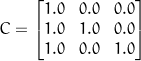

In [3]:
# SolutionToRemove

coord = np.array([
    [0, 0],
    [1, 0],
    [0, 1]
])

# C est construit en évaluant M en chaque point de l'élément
nb_point = 3
C = np.zeros([nb_point, nb_point])

for i in range(nb_point):
    x = coord[i, 0]
    y = coord[i, 1]
    C[i, :] = M(x, y) # for row i -> xi, yi = coord point i -> M = (1, x, y) -> row i = (1, xi, yi)

plot_matrix(C, 'C')

3. Programmez les fonctions d'interpolation du triangle rectangle ci-dessus.

In [4]:
# SolutionToRemove

C_inv = np.linalg.inv(C)
N = {}

for i in range(nb_point):
    N[i] = lambda x, y, i=i : M(x, y).dot(C_inv[:, i]) # col i from C_inv used to build Ni, Ni built as function of x, y we give later on

4. Programmez une vérification de la partition de l'unité: $\sum_i N_i(x, y) = 1$. Dans notre cas, ce critère est-il bien respecté partout?

In [5]:
# SolutionToRemove

for i in range(nb_point):
    x = coord[i, 0]
    y = coord[i, 1]
    somme = 0
    for j in range(nb_point):
        somme += N[j](x, y)
    print(f"Sum N_i({int(x), int(y)}) =", somme)

Sum N_i((0, 0)) = [1.]
Sum N_i((1, 0)) = [1.]
Sum N_i((0, 1)) = [1.]


5. Programmez une vérification des propriétés nodales: $N_i(x_j) = \delta_{ij}$.

In [6]:
# SolutionToRemove

for i in range(nb_point):
    for j in range(nb_point):
        x = coord[j, 0]
        y = coord[j, 1]
        print(f"N_{i}({int(x), int(y)}) = ", N[i](x, y))

N_0((0, 0)) =  [1.]
N_0((1, 0)) =  [0.]
N_0((0, 1)) =  [0.]
N_1((0, 0)) =  [0.]
N_1((1, 0)) =  [1.]
N_1((0, 1)) =  [0.]
N_2((0, 0)) =  [0.]
N_2((1, 0)) =  [0.]
N_2((0, 1)) =  [1.]


6. Utilisez votre programme pour calculer les fonctions d'interpolation d'un triangle de votre choix.

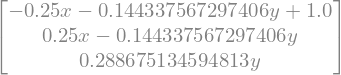

In [7]:
# SolutionToRemove

# Seules les coordonnées doivent être modifiées. Prenons par exemple, un triangle équilatéral dont les côtés valent 4 :

coord = np.array([
    [0, 0],
    [4, 0],
    [2, 2*np.sqrt(3)]
])

nb_point = 3
C = np.zeros([nb_point, nb_point])

for i in range(nb_point):
    x = coord[i, 0]
    y = coord[i, 1]
    C[i, :] = M(x, y)

C_inv = np.linalg.inv(C)

N = {}
for i in range(nb_point):
    N[i] = lambda x, y, i=i : (M(x, y).dot(C_inv[:, i]))[0]


x, y = symbols('x y')
Matrix((N[0](x, y), N[1](x, y), N[2](x, y)))

7. Comment adapteriez vous votre code pour des éléments finis carrés à quatre noeuds ?

SolutionToRemove

Le nombre de nœuds doit être adapté, ainsi que la matrice des monômes $M(x, y)$ qui doit contenir des coefficients xy. 